In [92]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

from metpy.calc import wind_speed
from metpy.calc import wind_direction 
from metpy.units import units

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'font.size' : 18})

# About
__Author:__ Pat McCornack  
__Date:__ 04/11/25  
__Purpose:__ Uses extracted netcdfs for standard meteorological variables and Chris Still met station data to evaluate WRF's performance.  

# Functions

# Load/Process Data

In [ ]:
root_dir = Path().resolve().parents[0]
wrf_data_dir = root_dir / 'data' / 'wrf'
met_df_fpath = root_dir /  'data' / 'weather-station' / 'combined-sites-clean.csv'
met_coords_fpath = root_dir / 'data' / 'weather-station' / 'sci-stations.csv'

wrf_dict = {'RH2' : wrf_data_dir / 'wrf-rh2.nc',
            'T2' : wrf_data_dir / 'wrf-T2.nc',
            'U10' : wrf_data_dir / 'wrf-U10.nc',  # x wind component (10m)
            'V10' : wrf_data_dir / 'wrf-V10.nc'}  # y wind component (10m)

met_coords = pd.read_csv(met_coords_fpath)  # Info about the weather stations
met_coords = met_coords.loc[~met_coords['station'].isin(['eend', 'eenc', 'crat', 'pozo-smo2', 'pozo-smo1'])]  # Drop irrelevant sites

## Process Weather Station Data

In [94]:
# Set up met_df
met_df = pd.read_csv(met_df_fpath)
met_df['time (PST)'] = pd.to_datetime(met_df['time (PST)'])
met_df.index

RangeIndex(start=0, stop=282430, step=1)

In [95]:
# Set up met_df
met_df = pd.read_csv(met_df_fpath)
met_df['time (PST)'] = pd.to_datetime(met_df['time (PST)'])
met_df = met_df.loc[~met_df['site'].isin(['eend', 'eenc', 'crat', 'pozo-smo2', 'pozo-smo1'])]  # Drop irrelevant sites
met_df.describe()


,time (PST),air temperature (C),relative humidity (%),wind speed (m/s),wind direction (deg),fog tips,rain (mm)
count,282430,271123.000000,247082.000000,264924.000000,256639.000000,282430.000000,282430.000000
mean,2006-10-02 07:05:05.247317760,15.648300,81.006026,1.690515,246.265233,0.121358,0.001521
min,2004-05-01 00:00:00,2.114000,3.014000,0.000000,0.000000,0.000000,0.000000
25%,2005-06-12 17:30:00,12.160000,70.800000,0.560000,177.300000,0.000000,0.000000
50%,2006-06-17 20:30:00,14.470000,88.300000,1.480000,294.799990,0.000000,0.000000
75%,2008-05-12 21:30:00,18.430000,97.700000,2.541000,319.400000,0.000000,0.000000
max,2011-09-30 23:00:00,40.670000,100.000000,9.650000,360.000000,185.000000,6.325000
std,NaN,4.831377,20.754043,1.360391,100.741953,0.745918,0.038803


In [96]:
# Set multiindex 
met_df = met_df.set_index(['site', 'time (PST)'])

## Process WRF data

In [97]:
# Extract dataframe from netcdfs using site coords
first_pass = True
for var, fpath in wrf_dict.items():  # For each variable
    var_df = pd.DataFrame()
    for i, row in met_coords.iterrows():  # For each station
        lat = row['latitude']
        lon = row['longitude']
        ds = xr.open_dataarray(wrf_dict[var])
        station_ds = ds.sel(lat=lat, lon=lon, method='nearest')
        station_df = station_ds.to_dataframe(name=var).reset_index()[['time', var]]
        station_df['site'] = row['station']

        station_df['time'] = pd.to_datetime(station_df['time'])
        station_df['time'] = station_df['time'] - pd.to_timedelta(1, unit='h')  # PDT to PST
        station_df = station_df.rename({'time' : 'time (PST)'}, axis=1)
        station_df = station_df.set_index(['site', 'time (PST)'])

        var_df = pd.concat([var_df, station_df])

    # Create single df with all variables
    if first_pass == True:
        wrf_df = var_df
    else:
        wrf_df = pd.merge(wrf_df, var_df, how='inner', left_index=True, right_index=True)
    
    first_pass = False

wrf_df.describe()


,RH2,T2,U10,V10
count,585179.000000,585179.000000,585179.000000,585179.000000
mean,69.397964,290.633636,2.342463,-1.729972
std,22.255562,5.408674,2.931606,2.346412
min,2.387302,0.000000,-15.134946,-12.375834
25%,54.739790,286.929840,0.546338,-3.280115
50%,71.825264,289.977692,2.611226,-1.616169
75%,87.442387,293.718628,4.293668,-0.178745
max,100.000000,313.371521,14.015853,7.244581


In [98]:
# Convert K to C
wrf_df['T2'] = wrf_df['T2'] - 273
wrf_df.loc[wrf_df['T2'] == -273, 'T2'] = np.nan  # Handle bad values

wrf_df['T2'].describe()

count    585144.000000
mean         17.650930
std           4.919634
min           5.605377
25%          13.930588
50%          16.978027
75%          20.719032
max          40.371521
Name: T2, dtype: float64

In [99]:
# Get wind speed/direction from components
u = wrf_df['U10'].values * units('m/s')
v = wrf_df['V10'].values * units('m/s')
wrf_df['wind_spd'] = wind_speed(u,v)
wrf_df['wind_dir'] = wind_direction(u, v, convention='from')
wrf_df = wrf_df.drop(['U10', 'V10'], axis=1)

wrf_df[['wind_spd', 'wind_dir']].describe()

,wind_spd,wind_dir
count,585179.000000,585179.000000
mean,4.094326,258.238586
std,2.411720,83.207382
min,0.007292,0.002151
25%,2.316391,227.073174
50%,3.611579,296.749329
75%,5.554199,311.518066
max,16.061771,359.999207


In [100]:
# Rename WRF columns
new_cols = []
for col in list(wrf_df.columns):
    new_cols.append(col + '_wrf')

wrf_df.columns = new_cols
wrf_df.head()

RH2_wrf     T2_wrf  wind_spd_wrf  wind_dir_wrf
site time (PST)                                                           
cair 1996-05-31 16:00:00  67.323349  16.843048      5.707997    292.702515
     1996-05-31 17:00:00  70.684212  16.279541      5.039712    293.075470
     1996-05-31 18:00:00  73.011337  15.763458      4.491889    293.207214
     1996-05-31 19:00:00  76.270844  14.929565      3.399316    290.956421
     1996-05-31 20:00:00  80.533516  14.153656      2.519886    288.491150

In [101]:
wrf_df.loc[wrf_df.index.duplicated()]  # There's a handful of duplicated rows

RH2_wrf  T2_wrf  wind_spd_wrf  wind_dir_wrf
site time (PST)                                                        
cair 2017-06-30 16:00:00  77.871269     NaN      7.784041    289.176758
     2017-06-30 16:00:00  77.871269     NaN      7.784041    289.176758
     2017-06-30 16:00:00  77.871269     NaN      7.784041    289.176758
     2017-06-30 16:00:00  77.871269     NaN      7.784041    289.176758
     2017-06-30 16:00:00  77.871269     NaN      7.784041    289.176758
cpin 2017-06-30 16:00:00  75.902428     NaN      7.627663    287.519043
     2017-06-30 16:00:00  75.902428     NaN      7.627663    287.519043
     2017-06-30 16:00:00  75.902428     NaN      7.627663    287.519043
     2017-06-30 16:00:00  75.902428     NaN      7.627663    287.519043
     2017-06-30 16:00:00  75.902428     NaN      7.627663    287.519043
crak 2017-06-30 16:00:00  75.591011     NaN      7.642098    287.854614
     2017-06-30 16:00:00  75.591011     NaN      7.642098    287.854614
     2017-06-30 16:00:00  75.591011     NaN      7.642098    287.854614
     2017-06-30 16:00:00  75.591011     NaN      7.642098    287.854614
     2017-06-30 16:00:00  75.591011     NaN      7.642098    287.854614
erdg 2017-06-30 16:00:00  75.623337     NaN      7.592692    287.182220
     2017-06-30 16:00:00  75.623337     NaN      7.592692    287.182220
     2017-06-30 16:00:00  75.623337     NaN      7.592692    287.182220
     2017-06-30 16:00:00  75.623337     NaN      7.592692    287.182220
     2017-06-30 16:00:00  75.623337     NaN      7.592692    287.182220
sauc 2017-06-30 16:00:00  76.857941     NaN      7.718330    288.190063
     2017-06-30 16:00:00  76.857941     NaN      7.718330    288.190063
     2017-06-30 16:00:00  76.857941     NaN      7.718330    288.190063
     2017-06-30 16:00:00  76.857941     NaN      7.718330    288.190063
     2017-06-30 16:00:00  76.857941     NaN      7.718330    288.190063
upem 2017-06-30 16:00:00  75.902428     NaN      7.627663    287.519043
     2017-06-30 16:00:00  75.902428     NaN      7.627663    287.519043
     2017-06-30 16:00:00  75.902428     NaN      7.627663    287.519043
     2017-06-30 16:00:00  75.902428     NaN      7.627663    287.519043
     2017-06-30 16:00:00  75.902428     NaN      7.627663    287.519043
wrdg 2017-06-30 16:00:00  77.451637     NaN      7.748378    288.848999
     2017-06-30 16:00:00  77.451637     NaN      7.748378    288.848999
     2017-06-30 16:00:00  77.451637     NaN      7.748378    288.848999
     2017-06-30 16:00:00  77.451637     NaN      7.748378    288.848999
     2017-06-30 16:00:00  77.451637     NaN      7.748378    288.848999

In [102]:
# Join dataframes
wrf_df = wrf_df.loc[~wrf_df.index.duplicated(keep='first')]  # drop duplicates
join_df = pd.concat([met_df, wrf_df], join='inner', axis=1)
join_df.head()

air temperature (C)  relative humidity (%)  \
site time (PST)                                                        
wrdg 2004-05-01 00:00:00                11.14              91.400002   
     2004-05-01 01:00:00                11.38              89.300003   
     2004-05-01 02:00:00                10.92              93.400002   
     2004-05-01 03:00:00                10.31              96.800003   
     2004-05-01 04:00:00                14.30              57.299999   

                          wind speed (m/s)  wind direction (deg)  fog tips  \
site time (PST)                                                              
wrdg 2004-05-01 00:00:00               NaN                   NaN       0.0   
     2004-05-01 01:00:00               NaN                   NaN       0.0   
     2004-05-01 02:00:00               NaN                   NaN       0.0   
     2004-05-01 03:00:00               NaN                   NaN       0.0   
     2004-05-01 04:00:00               NaN                   NaN       0.0   

                          rain (mm)    RH2_wrf     T2_wrf  wind_spd_wrf  \
site time (PST)                                                           
wrdg 2004-05-01 00:00:00        0.0  54.748169  13.137115      2.497973   
     2004-05-01 01:00:00        0.0  62.983200  12.895142      1.397564   
     2004-05-01 02:00:00        0.0  66.890579  12.341125      2.470944   
     2004-05-01 03:00:00        0.0  67.927650  12.308716      1.180518   
     2004-05-01 04:00:00        0.0  74.071526  11.583466      1.001990   

                          wind_dir_wrf  
site time (PST)                         
wrdg 2004-05-01 00:00:00    297.387451  
     2004-05-01 01:00:00    300.811401  
     2004-05-01 02:00:00    296.724335  
     2004-05-01 03:00:00    312.325439  
     2004-05-01 04:00:00    310.685883

# Statistics
Compare bias, correlation, rmse, and mae by site and variable. 

In [186]:
# Calculate statistics

var_list = [
    ['relative humidity (%)', 'RH2_wrf'],
    ['air temperature (C)', 'T2_wrf'],
    ['wind speed (m/s)', 'wind_spd_wrf'],
    ['wind direction (deg)', 'wind_dir_wrf']
]

stats_df = pd.DataFrame()
for site in join_df.index.get_level_values('site').unique().tolist():  # For every site
    site_df = join_df.loc[join_df.index.get_level_values('site') == site]

    for vars in var_list:  # For every variable
        df = pd.DataFrame({vars[0] : site_df[vars[0]], vars[1] : site_df[vars[1]]})  # Temporary df with just variables of interest 
        df = df.dropna()

        bias = np.mean((df[vars[1]] - df[vars[0]]))
        mae = np.mean(np.abs(df[vars[1]] - df[vars[0]]))
        rmse = np.sqrt(np.mean((df[vars[1]] - df[vars[0]])**2))
        corr = np.corrcoef(df[vars[0]], df[vars[1]])

        stat_dict = {
            'site' : site,
            'var' : vars[0],
            'correlation' : corr[0,1],
            'bias' : bias,
            'mae' : mae,
            'rmse' : rmse
        }

        site_stats = pd.DataFrame([stat_dict])
        stats_df = pd.concat([stats_df, site_stats], axis=0)
stats_df

,site,var,correlation,bias,mae,rmse
0,wrdg,relative humidity (%),0.710949,-11.979232,12.923017,17.091555
0,wrdg,air temperature (C),0.859398,1.053974,1.686656,2.297847
0,wrdg,wind speed (m/s),0.637658,2.001724,2.022402,2.367776
0,wrdg,wind direction (deg),0.300666,12.156270,51.455376,87.986373
0,sauc,relative humidity (%),0.711781,-9.414591,13.133636,17.661513
0,sauc,air temperature (C),0.805013,2.244518,2.787895,3.689927
0,sauc,wind speed (m/s),0.686449,2.685368,2.775112,3.246392
0,sauc,wind direction (deg),0.510387,-7.149918,51.225323,93.861754
0,cpin,relative humidity (%),0.720783,-13.028940,16.300850,21.361933
0,cpin,air temperature (C),0.829309,1.906466,2.615630,3.486073


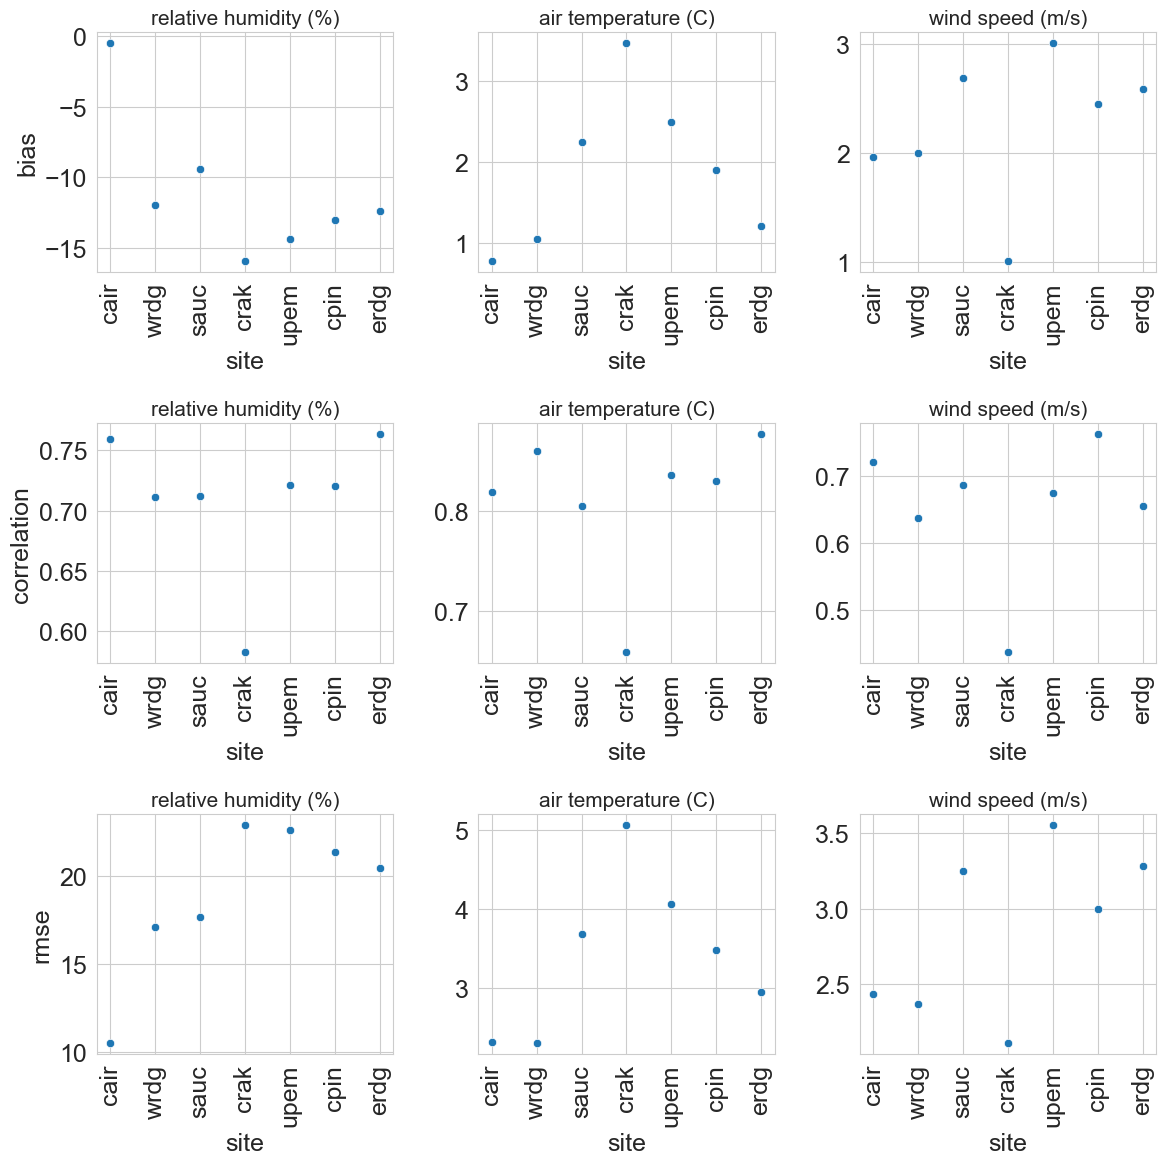

In [193]:

variables = ['relative humidity (%)', 'air temperature (C)', 'wind speed (m/s)']
metrics = ['bias', 'correlation', 'rmse']
site_order = ['cair', 'wrdg', 'sauc', 'crak', 'upem', 'cpin', 'erdg']  # Ordered West -> East

fig, axes = plt.subplots(3,3, figsize=(12,12))

for row, metric in enumerate(metrics):
    for col, var in enumerate(variables):
        ax = axes[row, col]
        var_df = stats_df.loc[stats_df['var'] ==  var].copy().reset_index(drop=True)
        var_df['site'] = pd.Categorical(var_df['site'], categories=site_order, ordered=True)
        sns.scatterplot(data=var_df, x='site', y=metric, ax=ax)
        
        # Set titles and labels
        ax.set_title(var, fontsize=15)
        if col == 0:
            ax.set_ylabel(metric)
        else:
            ax.set_ylabel("")

        # Rotate xticks if on bottom row
        ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()
